# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers + summaries
    read_hrs1, read_hrs2, find_hrs_files,
    print_hrs1_summary, print_hrs2_summary,
    # Post-hoc global windowing
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    run_direct_bg_sweep, plot_direct_bg_sweep,
    # M/H response metrics (per-trial normalized)
    compute_mh_metrics, compute_mh_variability_sweep,
    plot_mh_variability, print_mh_variability_summary, view_mh_bin,
    # Section 5 quartile window comparison
    plot_quartile_window_comparison,
    # EMG window optimization
    compute_optimization_scores, plot_optimization, print_optimization_summary,

    plot_amplitude_distribution, plot_background_emg_views,
    simulate_trial_initiation_hrs,
    split_trials_by_polarity, plot_hm_ratio_summary,

    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [2]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
#
# Latest recordings (HRS2 v5, may include background_emg_mean + background_bins):
#   HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026  -- HRS2 v5, 5 kHz, with background_bins
#   D1_5KHZ_HRPILOT16_B_5-11-26               -- HRS2 v5, 5 kHz, background_emg_mean only
#
# New-format HRPILOT recordings (HRS1 includes sample_rate field, HRS2 v4):
#   D1_HRPILOT16_A_5-11-26                    -- 10 kHz, HRS2 v4
#   D1_HRPILOT16_B_5-11-26                    -- 10 kHz, HRS2 v4
#   HRPILOT-16-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-16-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#   HRPILOT-16_A_CONTROL_MODE_5-5-26          -- control-mode session     (HRS2 v4)
#
# Legacy polarity / hour-test recordings (no sample_rate in HRS1 header):
#   Polarity_Tests/HR-08-POLARITY_TEST_CORRECT   -- electrodes attached correctly
#   Polarity_Tests/HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached flipped
#   Polarity_Tests/HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)

recording_dir = "D2_HRPILOT16_CONTROL_MODE_B_5-14-26"
recording_sample_rate = None  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect from HRS1 header

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found â HRS2 sections will be skipped")


Recording directory: D2_HRPILOT16_CONTROL_MODE_B_5-14-26
  HRS1 file: D2_HRPILOT16_CONTROL_MODE_B_5-14-26_20260514T145506.hrs1
  HRS2 file: D2_HRPILOT16_CONTROL_MODE_B_5-14-26_20260514T145615.hrs2


In [3]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)

=== HRS1 Header ===
  File:               D2_HRPILOT16_CONTROL_MODE_B_5-14-26_20260514T145506.hrs1
  File version:       1
  Subject ID:         D2_HRPILOT16_CONTROL_MODE_B_5-14-26
  Session datetime:   2026-05-14 14:55:06.366891
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        5000.0 Hz
  Trials/hr data: centre=249.14 µV, elapsed=0.006 h, 20 window sizes

  Trials found:       7
  EMG data blocks:    535

=== First Trial ===
  End datetime:       2026-05-14 14:55:09.016022
  Start index:        170741
  Grand mean:         209.3071
  Bins count:         52
  Monitored signal N: 13000

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:       7 x 191 samples
  Diff samples:       191
  Filtered samples:   191
  Abs

# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [4]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found — skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
    print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)

=== HRS2 Header ===
  File:               D2_HRPILOT16_CONTROL_MODE_B_5-14-26_20260514T145615.hrs2
  File version:       6  (v6: + stim_polarity_reversed)
  Subject ID:         D2_HRPILOT16_CONTROL_MODE_B_5-14-26
  Session start time: 2026-05-14 14:56:15.267292
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       372
  EMG data blocks:    268699
  Stim polarity:      0 normal, 372 reversed  ← dual-polarity session

=== First EMG Block ===
  Channel names:  ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:   7 x 191 samples
  Diff samples:   191


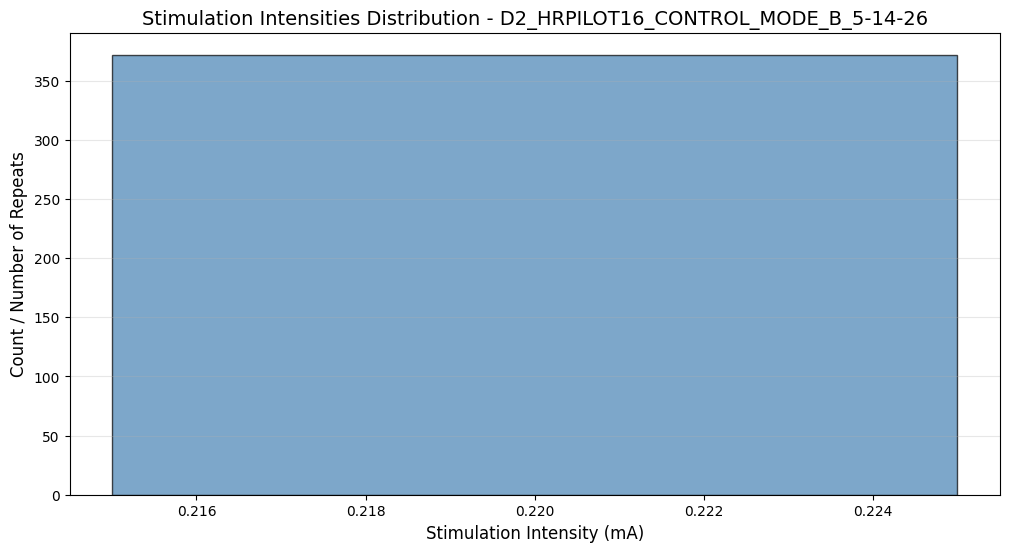

Reconstructed background bins for 372/372 trials (window=2500 ms).


In [5]:
# ---- Histogram of stimulation intensities ----


plot_amplitude_distribution(hrs2_trials, hrs2_header)

# ---- "Most recent background" + "Background EMG Level" plots ----
# Mirrors the H-Reflex App recruitment-curve trial plot widgets.
plot_background_emg_views(hrs2_trials, hrs2_emg_blocks, monitoring_window_ms=2500,
                          sample_rate=recording_sample_rate or hrs1_header.sample_rate)


# Section 4: Post-Hoc Background EMG Analysis

Reconstruct the continuous abs-EMG signal from HRS2 EMG blocks, blank around each stimulation event, compute background statistics, extract per-trial pre-stim grand means, and run the direct background sweep.

**Steps:**
1. **4a** — Sort and stitch all HRS2 EMG blocks into one continuous signal.
2. **4b** — Build a blank mask that suppresses samples within ±[`blank_pre_ms`, `blank_post_ms`] of every stimulation event.
3. **4c** — Compute global background EMG statistics from the non-blanked signal.
4. **4d** — Extract each trial's pre-stim background grand mean and plot the distribution.
5. **4e** — Run the direct per-trial background sweep (EMG window width vs matched trials).

In [6]:
# ---- Section 4: Post-hoc background EMG analysis ----
state = analyze_global_background(
    hrs2_trials, hrs2_emg_blocks, hrs2_header,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    blank_pre_ms=5, blank_post_ms=20,
    min_valid_frac=0.7,
)

Section 4a: Reconstructing continuous signal from HRS2 EMG blocks
  Blocks stitched : 268,699
  Total samples   : 11,331,391
  Duration        : 2266.3 s  (37.8 min)
  OE sample range : 1778788575164 – 1778799906555
  Gap samples     : 1,095,941  (9.672% of total)

Section 4b: Building blank mask around stimulation events
Blank mask: 0 events -> 0 samples blanked (0.0000 fraction)
  Stim events mapped  : 0 of 372
  Unmapped (no onset) : 372
  Non-blanked samples : 11,331,391  (100.0%)

Section 4c: Background EMG statistics (non-blanked samples)
  n       : 11,331,391
  Mean    : 172.141 µV
  Std     : 222.031 µV
  Q1      : 15.133 µV
  Median  : 93.998 µV
  Q3      : 254.246 µV

Section 4d: Per-trial pre-stim background grand means
  Trials : 372  (failed reconstruction: 0)
  Min=206.35  Q1=248.12  Median=263.43  Q3=282.22  Max=323.85
  Recorded thresholds (mean): [184.38, 320.00] µV


# Section 4b: Virtual Trial Rate Sweep

Walks the continuous background EMG signal (with stim periods blanked) using the
same state machine as the H-Reflex app: random monitoring windows 2200–2700 ms,
50 ms bins, accepts when all bin grand means fall within the threshold window.

**Output**: virtual trial rate (trials/hour) vs EMG window half-width,
evaluated at Q1, Median, and Q3 of the background distribution.

This is the primary sweep used by the **Section 7 Optimization**.

Section 4b: Running post-hoc virtual trial rate sweep
Signal duration : 2266.3 s | Non-blanked: 100.0%
Background stats: mean=172.14  Q1=248.12  Med=263.43  Q3=282.22 µV

  Q1     (centre=248.12 µV):  ±5→125.5/hr  ±10→176.3/hr  ±20→297.1/hr  ±30→448.0/hr  ±45→683.1/hr  ±60→945.2/hr  ±75→1067.5/hr  ±100→1188.2/hr  ±125→1259.7/hr  ±150→1321.6/hr
  Median (centre=263.43 µV):  ±5→49.2/hr  ±10→74.7/hr  ±20→127.1/hr  ±30→220.8/hr  ±45→448.0/hr  ±60→686.2/hr  ±75→935.6/hr  ±100→1131.0/hr  ±125→1218.4/hr  ±150→1281.9/hr
  Q3     (centre=282.22 µV):  ±5→14.3/hr  ±10→22.2/hr  ±20→41.3/hr  ±30→74.7/hr  ±45→181.1/hr  ±60→387.6/hr  ±75→627.5/hr  ±100→997.6/hr  ±125→1154.8/hr  ±150→1235.9/hr


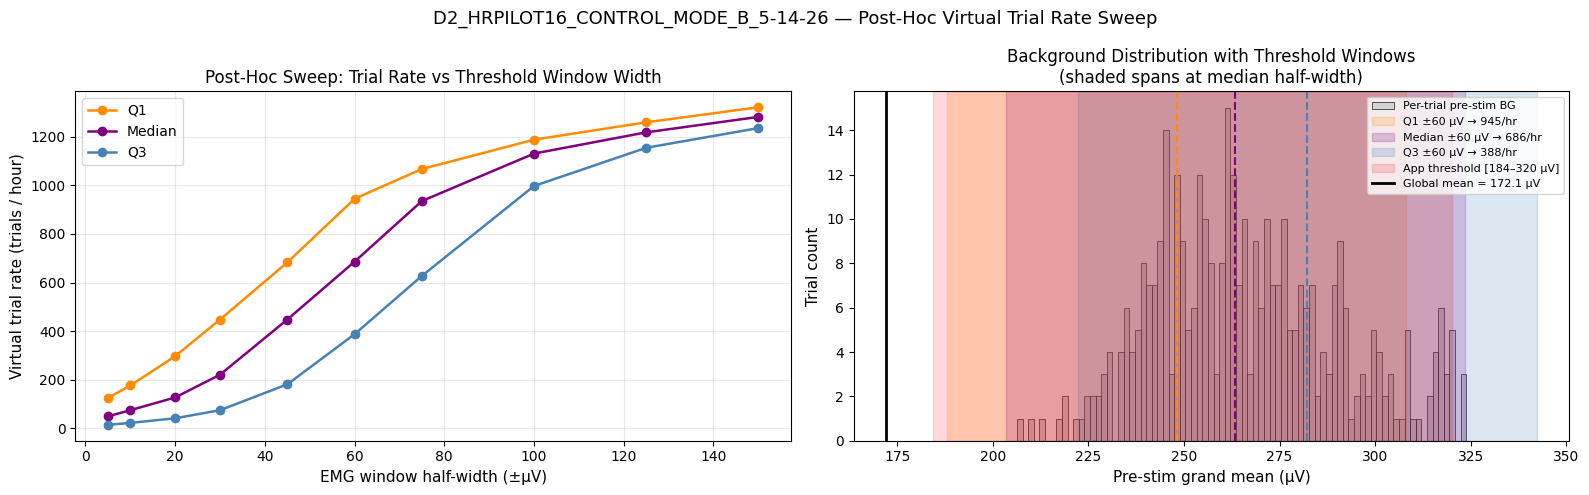


Session duration: 2266 s  (0.630 h)
Global EMG grand mean = 172.141 µV  (std=222.031, Q1=15.133, median=93.998, Q3=254.246)

    Centre   ±hw (µV)   Min (µV)   Max (µV)   Accepted    Trials/hr
-------------------------------------------------------------------
        Q1          5     243.12     253.12         79        125.5
        Q1         10     238.12     258.12        111        176.3
        Q1         20     228.12     268.12        187        297.1
        Q1         30     218.12     278.12        282        448.0
        Q1         45     203.12     293.12        430        683.1
        Q1         60     188.12     308.12        595        945.2
        Q1         75     173.12     323.12        672       1067.5
        Q1        100     148.12     348.12        748       1188.2
        Q1        125     123.12     373.12        793       1259.7
        Q1        150      98.12     398.12        832       1321.6

    Median          5     258.43     268.43         31   

In [7]:
# ---- Section 4b: Virtual trial rate sweep ----
# sweep_centres and half_widths_uv are reused by the M-H variability sweep
# in Section 6a -- keep them consistent for Section 7 optimization.
sweep_centres  = {'Q1': state['gm_q1'], 'Median': state['gm_med'], 'Q3': state['gm_q3']}
half_widths_uv = [5, 10, 20, 30, 45, 60, 75, 100, 125, 150]

sweep_results = run_threshold_sweep(
    state, sweep_centres=sweep_centres, half_widths_uv=half_widths_uv,
)
plot_threshold_sweep(sweep_results, state, hrs2_trials, hrs2_header)

# Section 4c: Direct Background Trial Count (Reference)

Retrospective count: of the **actual HRS2 trials recorded**, how many had a
pre-stimulus background grand mean within each threshold window?

> **Note**: this does *not* simulate trial rate — it only counts trials that
> *were already collected* whose background happened to be in-window.
> For prospective trial rate estimation, see Section 4b above.

Section 5a: Direct per-trial background sweep
  Background window → 1 µV bins → mean per bin → grand mean
  Actual HRS2 trials : 372
  Background Q1=248.12  Median=263.43  Q3=282.22 µV

  Q1     (centre=248.12 µV):  ±5→58  ±10→114  ±20→194  ±30→257  ±50→326  ±75→371  ±100→372  ±150→372
  Median (centre=263.43 µV):  ±5→59  ±10→118  ±20→218  ±30→296  ±50→346  ±75→372  ±100→372  ±150→372
  Q3     (centre=282.22 µV):  ±5→35  ±10→84  ±20→159  ±30→234  ±50→351  ±75→371  ±100→372  ±150→372

    Centre   ±hw (µV)   Min (µV)   Max (µV)    Matched   Fraction  BG Grand Mean
--------------------------------------------------------------------------------
        Q1          5     243.12     253.12         58     15.6%         248.13
        Q1         10     238.12     258.12        114     30.6%         248.13
        Q1         20     228.12     268.12        194     52.2%         248.57
        Q1         30     218.12     278.12        257     69.1%         250.33
        Q1         50     198

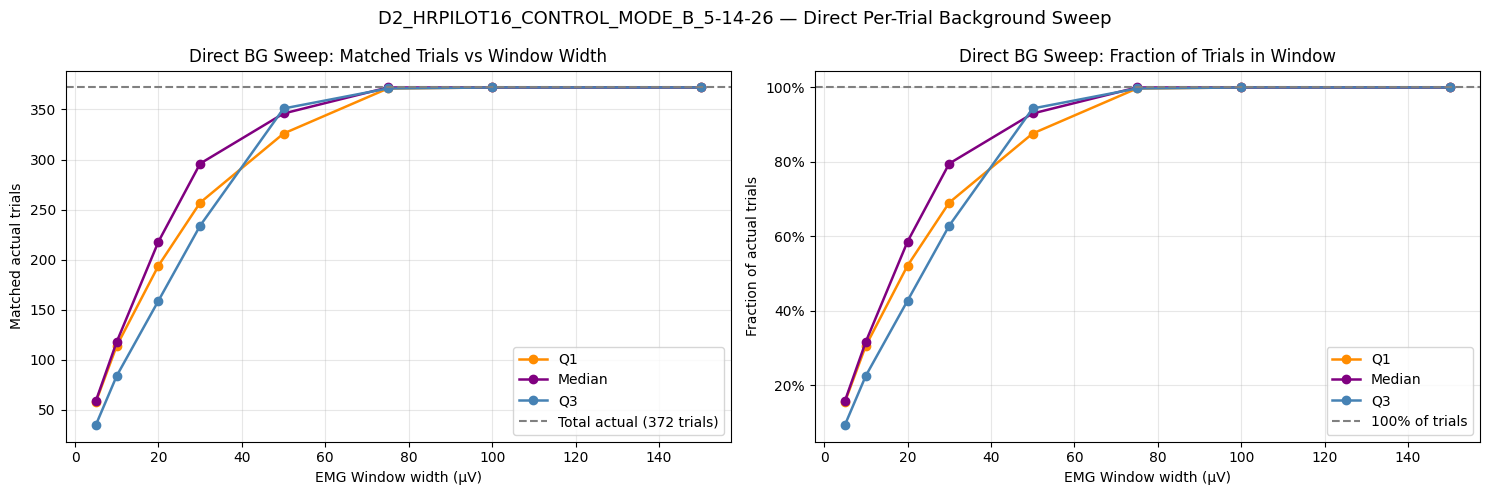

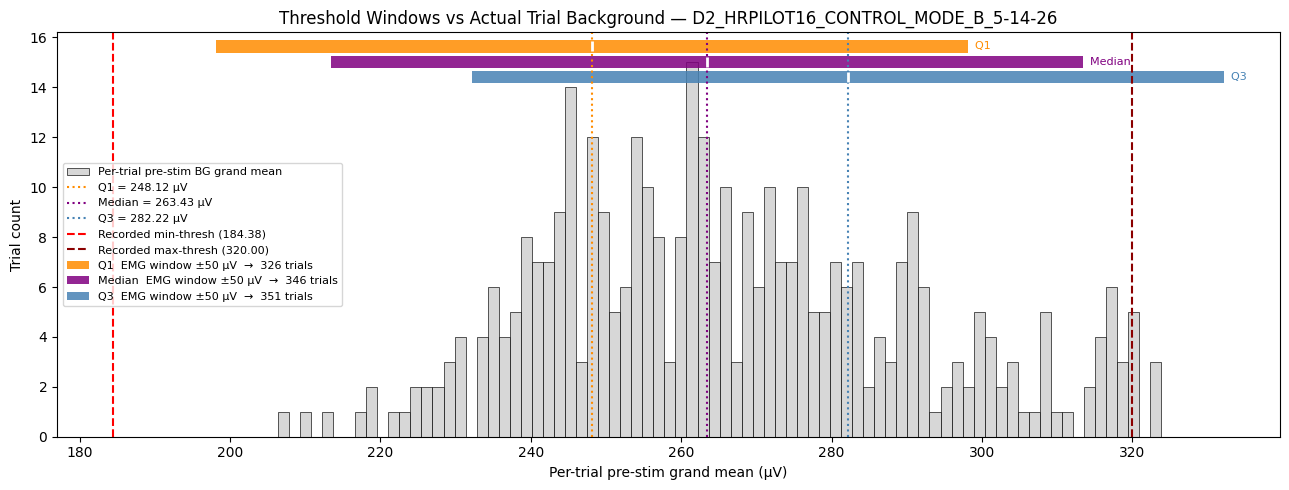

In [8]:
# ---- Section 4c: Direct background trial count (retrospective reference) ----
direct_bg_results = run_direct_bg_sweep(state)
plot_direct_bg_sweep(direct_bg_results, state, hrs2_trials, hrs2_header)

# Section 4d: Trial Initiation Simulator

Re-runs the H-Reflex app's trial-initiation state machine on the recorded EMG signal.

- **HRS1 source**: uses background EMG blocks from the EMG Characterization stage (no stim blanking).
- **HRS2 source**: uses peri-stim EMG blocks from the Recruitment Curve stage; samples around each stim onset are zeroed so stim artifacts cannot trigger initiation.

Set `SIM_SOURCE`, `SIM_MIN_UV`, `SIM_MAX_UV`, and `SIM_MIN_ITI_MS` in the cell below, then run it.

Trial Initiation Simulator — HRS1 source | HRPILOT-18_EMG_CHARACTERIZATION_5-12-2026
  Blocks stitched : 97,819
  Total samples   : 3,702,049  (740.4 s / 12.3 min)
  Sample rate     : 5000 Hz
  Thresholds      : 15.0 – 300.0 µV
  Min ITI         : 3000 ms

STARTING TRIAL INITIATION SIMULATION (with bin sliding)
Total samples: 3,702,049 | Duration: 740.41s
Thresholds: 15.0 - 300.0 uV
Min ITI: 3000 ms | Block: 50 samples | Bin slide: 50 ms (250 samples)

[NOT_SETUP -> WAIT] Attempt #1 | Window: 2550 ms | Time: 0.00s
  [IMMEDIATE] Trial #1 | GM:257.51 uV | Window:2550 ms | Time:2.55s | ISI:5550 ms

[NOT_SETUP -> WAIT] Attempt #2 | Window: 2250 ms | Time: 2.56s
  [IMMEDIATE] Trial #2 | GM:258.38 uV | Window:2250 ms | Time:7.79s | ISI:5240 ms

[NOT_SETUP -> WAIT] Attempt #3 | Window: 2200 ms | Time: 7.80s
  [IMMEDIATE] Trial #3 | GM:229.69 uV | Window:2200 ms | Time:12.98s | ISI:5190 ms

[NOT_SETUP -> WAIT] Attempt #4 | Window: 2600 ms | Time: 12.99s
  [IMMEDIATE] Trial #4 | GM:207.29 uV | 

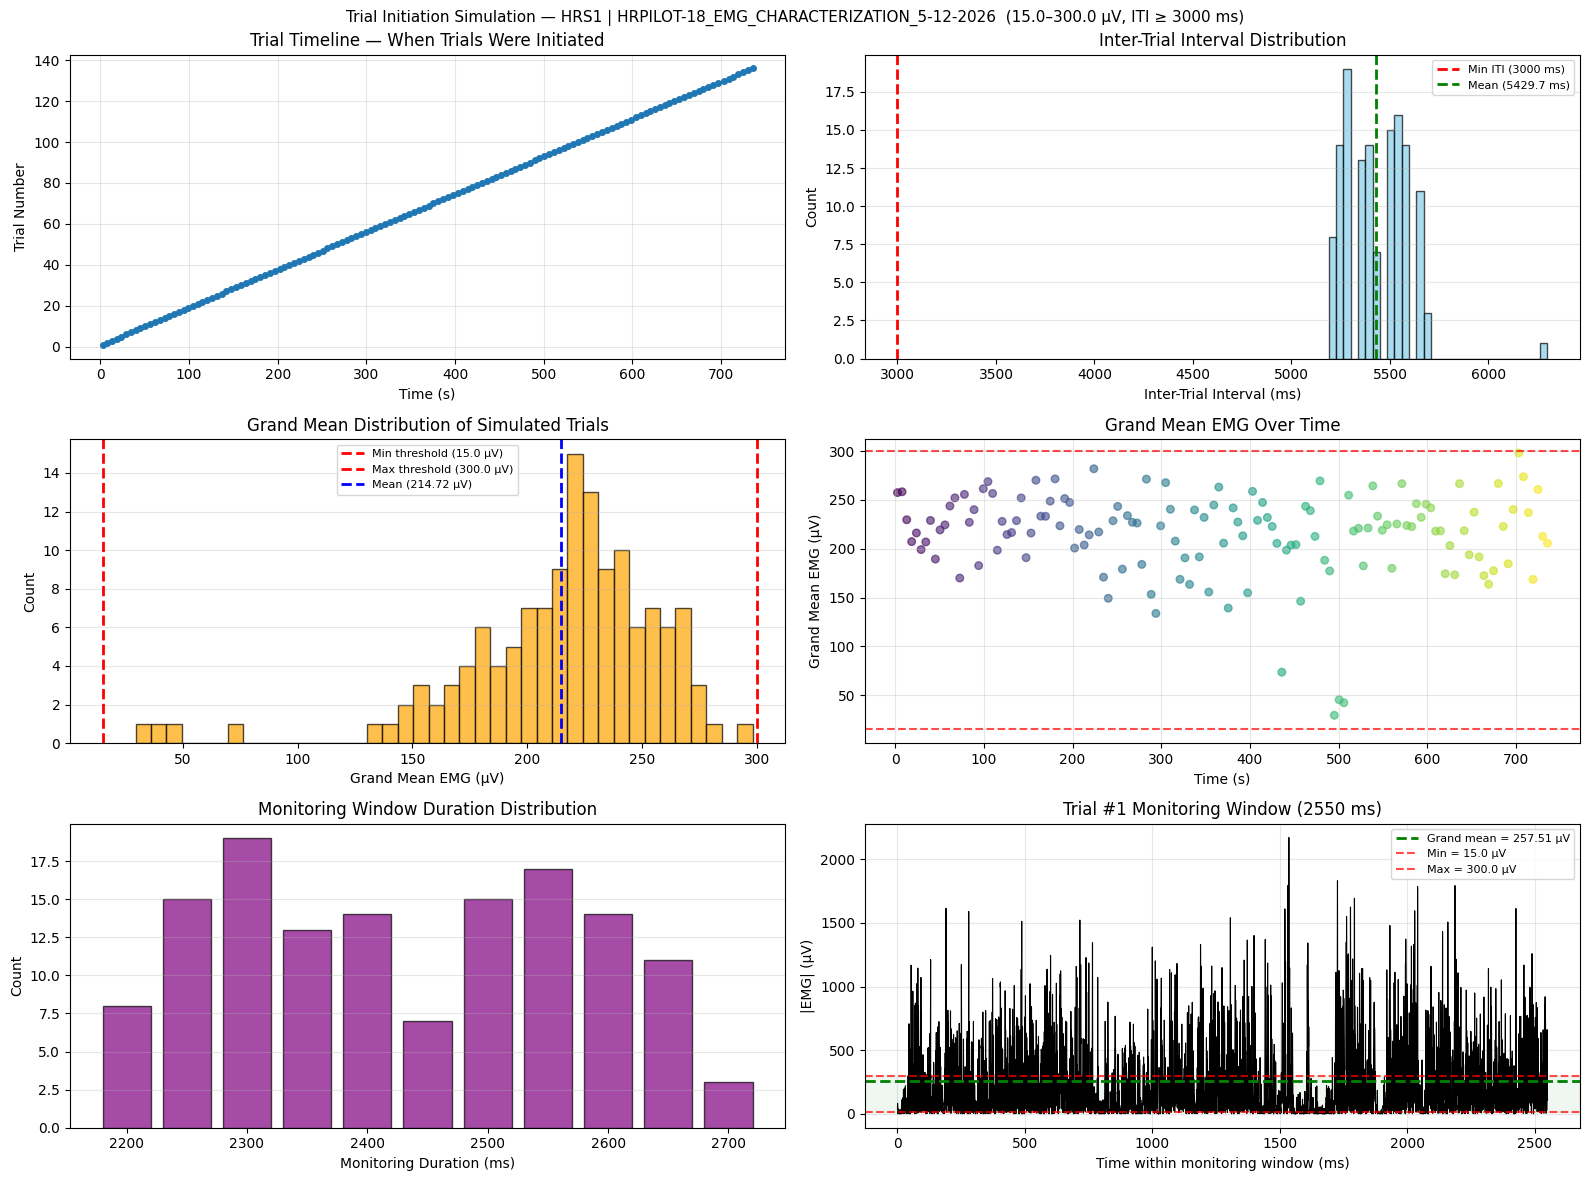

TRIAL RATE ANALYSIS
--------------------------------------------------------------------------------
Recording Duration:            0.206 hours  (740.4 s)
Total Simulated Trials:        136
Trials per Hour:               661.3
--------------------------------------------------------------------------------

SIMULATION ANALYSIS COMPLETE


In [9]:
# ---- Section 4d: Trial Initiation Simulation ----
#
# SIM_SOURCE: which EMG blocks to use
#   "hrs1" -- background EMG from the EMG Characterization stage (no stim blanking)
#   "hrs2" -- peri-stim EMG from the Recruitment Curve stage (stim periods zeroed)
SIM_SOURCE      = "hrs1"   # "hrs1" or "hrs2"

# Initiation thresholds (µV). Set to None to read from hrs1_header.
SIM_MIN_UV      = None     # e.g. 50.0  or None
SIM_MAX_UV      = None     # e.g. 200.0 or None

# Minimum inter-trial interval (ms)
SIM_MIN_ITI_MS  = 3000

# Stim blanking window used in HRS2 mode
SIM_BLANK_PRE_MS  = 5.0
SIM_BLANK_POST_MS = 20.0

_emg_blocks = hrs1_emg_blocks if SIM_SOURCE == "hrs1" else hrs2_emg_blocks
_sim_header = hrs1_header     if SIM_SOURCE == "hrs1" else hrs2_header
_trials_for_blank = None      if SIM_SOURCE == "hrs1" else hrs2_trials

# Default thresholds come from the HRS1 file header (what the app actually used)
_sim_min = SIM_MIN_UV if SIM_MIN_UV is not None else float(hrs1_header.trial_initiation_uv_min)
_sim_max = SIM_MAX_UV if SIM_MAX_UV is not None else float(hrs1_header.trial_initiation_uv_max)

simulated_trials, sim_statistics = simulate_trial_initiation_hrs(
    _emg_blocks,
    _sim_header,
    hrs2_trials=_trials_for_blank,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    min_init_uv=_sim_min,
    max_init_uv=_sim_max,
    min_inter_trial_ms=SIM_MIN_ITI_MS,
    blank_pre_ms=SIM_BLANK_PRE_MS,
    blank_post_ms=SIM_BLANK_POST_MS,
)

# Section 5: Quartile Window Comparison

For a fixed **EMG window width** (±`hw_uv` µV), compare the trials selected by windows
centred on **Q1**, **Median**, and **Q3** of the background distribution.

- **Plot 1** — histogram of per-trial background with shaded EMG windows for each quartile.
- **Interactive viewer** — dropdown selects Q1 / Median / Q3 / All:
  - *Left*: peri-stimulus waveforms (−2 ms to 15 ms), M/H window shading,
    group avg (black) + SEM, overall recording avg (blue).
  - *Right*: 2500 ms pre-stimulus background, same group vs overall overlays.

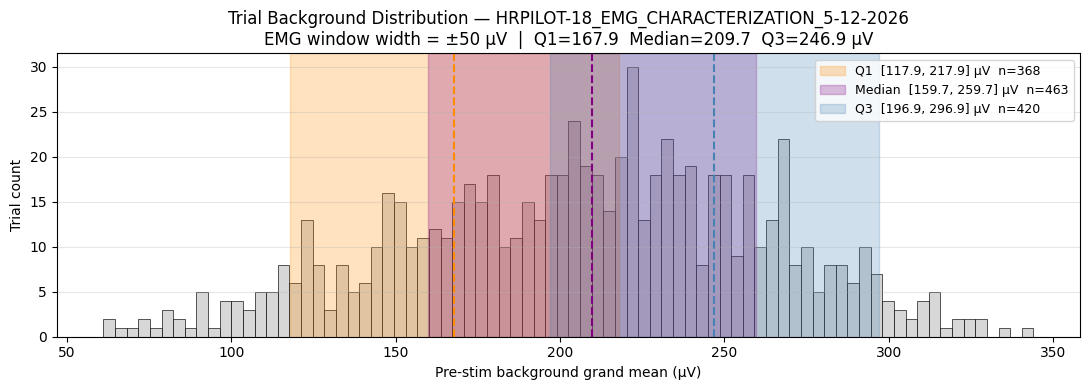

Pre-computing 2500 ms background bins for 752 trials… done.
Pre-computing overall averages… done  (752 peri-stim trials).


In [10]:
# ---- Section 5: Quartile window comparison (fixed EMG window width) ----
M_START_MS_S5, M_END_MS_S5 = 2.5, 5.5
H_START_MS_S5, H_END_MS_S5 = 7, 11.5

plot_quartile_window_comparison(
    hrs2_trials, hrs2_emg_blocks, state, hrs2_header,
    hw_uv=50,
    pre_ms=2.0, post_ms=15.0,
    bg_pre_ms=2500.0,
    m_start_ms=M_START_MS_S5, m_end_ms=M_END_MS_S5,
    h_start_ms=H_START_MS_S5, h_end_ms=H_END_MS_S5,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 6: M-/H-Response Variability vs EMG Window Size

For every trial we measure three response metrics inside the M and H windows,
each normalised to that trial's own pre-stim background grand mean:

- **M-H Peak (MRA)** — `mean(|emg|)` in the M or H window  (µV)
- **H/M Ratio** — `H-MRA / M-MRA` per trial
- **M-H Size** — `(MRA − per_trial_bg) / per_trial_bg`  (units of background activity)

For centres at **Q1 / Median / Q3** of the background distribution we sweep a
EMG window width `hw`, group trials whose background falls in `[centre ± hw]`, and
compute STD and CV (Coefficient of Variation = STD / Mean) for all metrics.

Output:
1. A 3 × 2 figure — STD (left) and CV (right) for M-H Peak, H/M Ratio, M-H Size.
2. A summary table at the 10 marker EMG window widths.
3. An interactive bin viewer.

In [11]:
# ---- Section 6a: Per-trial M-H metrics (per-trial background normalization) ----
M_START_MS, M_END_MS = 3.0, 5.5
H_START_MS, H_END_MS = 6.5, 11.5

mh_metrics = compute_mh_metrics(
    hrs2_trials, state['trial_bg_gm'],
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

sweep_centres  = {'Q1': state['gm_q1'], 'Median': state['gm_med'], 'Q3': state['gm_q3']}
half_widths_uv = [5, 10, 20, 30, 45, 60, 75, 100, 125, 150]

mh_variability = compute_mh_variability_sweep(
    state['trial_bg_gm'], mh_metrics, sweep_centres, half_widths_uv,
)

n = len(hrs2_trials)
print(f"Computed M-H metrics for {n} trials (per-trial background normalization)")
print(f"M window: {M_START_MS}–{M_END_MS} ms  |  H window: {H_START_MS}–{H_END_MS} ms")
print()
for key, label in [('m_mra',    'M-MRA (µV)     '),
                   ('h_mra',    'H-MRA (µV)     '),
                   ('hm_ratio', 'H/M ratio       '),
                   ('m_size',   'M-size (×bg)   '),
                   ('h_size',   'H-size (×bg)   ')]:
    arr = mh_metrics[key]
    v = arr[~np.isnan(arr)]
    if len(v) == 0:
        print(f"  {label}: no valid data")
        continue
    print(f"  {label}  n={len(v)}  mean={np.mean(v):.4f}  "
          f"std={np.std(v, ddof=1):.4f}  median={np.median(v):.4f}  "
          f"min={np.min(v):.4f}  max={np.max(v):.4f}")


Computed M-H metrics for 752 trials (per-trial background normalization)
M window: 3.0–5.5 ms  |  H window: 6.5–11.5 ms

  M-MRA (µV)       n=752  mean=1008.5220  std=591.6145  median=1045.8829  min=4.1563  max=2754.5876
  H-MRA (µV)       n=752  mean=252.3993  std=131.5166  median=233.7217  min=3.3881  max=1070.9716
  H/M ratio         n=752  mean=0.6587  std=2.3430  median=0.2480  min=0.0269  max=53.8203
  M-size (×bg)     n=752  mean=4.3509  std=3.8147  median=4.0569  min=-0.9761  max=24.7414
  H-size (×bg)     n=752  mean=0.2654  std=0.6755  median=0.1712  min=-0.9805  max=5.4971


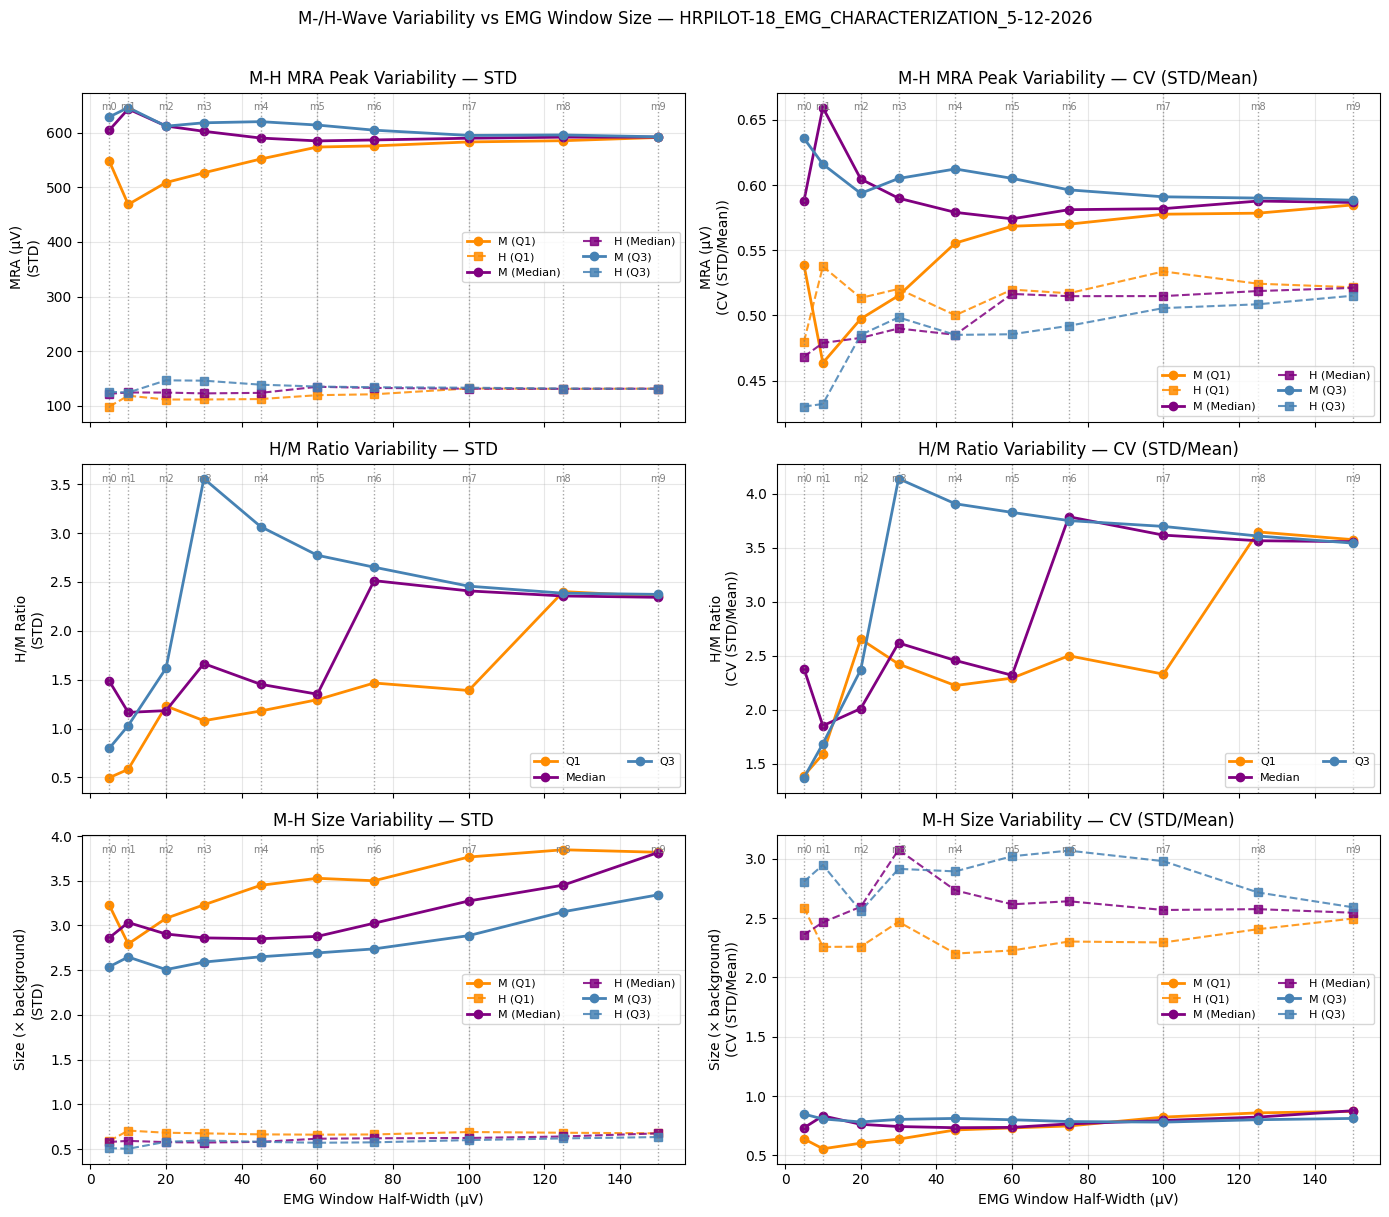

Marker EMG window widths: ['5.0', '10.0', '20.0', '30.0', '45.0', '60.0', '75.0', '100.0', '125.0', '150.0']


In [12]:
# ---- Section 6b: Variability plot (3 rows x 2 cols: STD / CV) ----
marker_hws = plot_mh_variability(mh_variability, hrs2_header, marker_hws=half_widths_uv)
print(f"Marker EMG window widths: {[f'{hw:.1f}' for hw in marker_hws]}")

In [13]:
# ---- Section 6c: Summary table at the 10 marker EMG window widths ----
mh_at_markers = compute_mh_variability_sweep(
    state['trial_bg_gm'], mh_metrics, sweep_centres,
    half_widths_uv=marker_hws,
)
print_mh_variability_summary(mh_at_markers, sweep_centres, hrs2_header,
                              marker_hws=marker_hws)


=== HRPILOT-18_EMG_CHARACTERIZATION_5-12-2026 — M-H variability summary ===
    Centre   ±hw (µV)      n   M-MRA STD   H-MRA STD   H/M STD   M-sz STD   H-sz STD   M-MRA CV   H-MRA CV   H/M CV
-------------------------------------------------------------------------------------------------------------------
        Q1        5.0     36     547.811      98.835     0.497      3.227      0.590      0.539      0.480    1.391
        Q1       10.0     79     468.389     118.676     0.583      2.793      0.707      0.464      0.538    1.590
        Q1       20.0    149     508.529     111.702     1.230      3.080      0.683      0.497      0.513    2.654
        Q1       30.0    218     526.348     111.754     1.080      3.230      0.676      0.515      0.520    2.424
        Q1       45.0    332     551.476     112.557     1.180      3.449      0.664      0.555      0.500    2.225
        Q1       60.0    441     573.432     119.657     1.295      3.527      0.661      0.568      0.520    2

In [14]:
# ---- Section 6d: Interactive bin viewer ----
view_mh_bin(
    mh_at_markers, marker_hws, hrs2_trials, mh_metrics, hrs2_header,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    emg_blocks=hrs2_emg_blocks,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)


Pre-computing 0 ms background for each trial… done  (0/752 trials).
Pre-computing overall averages… done  (peri-stim: 752, full-window: 0 trials).


# Section 6e: H:M Ratio Summary

Box plot and histogram of H:M ratio per stimulation polarity group.
Shows distribution shape, standard deviation, CV, and 20th/80th percentiles.

In [ ]:
# ---- Stim polarity split ----
trials_by_polarity = split_trials_by_polarity(hrs2_trials)

# ---- H:M Ratio Summary: box plot + histogram ----
# Uses the same M/H windows defined in Section 6a.
plot_hm_ratio_summary(
    trials_by_polarity, hrs2_header,
    m_start_ms=M_START_MS, m_end_ms=M_END_MS,
    h_start_ms=H_START_MS, h_end_ms=H_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 7: EMG Window Optimization

## Problem

Choose the best **EMG window** — defined by two decision variables:

| Decision variable | Options |
|---|---|
| **Window Location** (centre) | Q1, Median, or Q3 of the background EMG distribution |
| **Window Size** (EMG window width, ±hw µV) | narrow (±5 µV) → wide (±150 µV) |

## Objectives (simultaneously)

1. **Maximize trial rate** — a wider or better-placed window accepts more trials per session
2. **Minimize M-H variability** — a narrower window selects more uniform background states → more consistent M/H responses

These two objectives **conflict**: larger windows accept more trials but also let in more variable background states.

## Composite score

$$\text{score} = \alpha \times \text{trial\_score} + (1 - \alpha) \times \text{consistency\_score}$$

Both components are independently normalized to **[0, 1]** across all (centre, hw) pairs, so they are directly comparable regardless of units.

| α value | Priority |
|---|---|
| α = 1.0 | Maximize trials only |
| α = 0.5 | Balanced trade-off (default) |
| α = 0.0 | Minimize variability only |

## Pareto front

A (centre, hw) pair is **Pareto-optimal** if no other pair has *both* more trials *and* lower variability — i.e., you cannot improve one objective without hurting the other.
The Pareto front defines the set of efficient operating points.

## Outputs

- **Section 7a**: Compute scores + print ranked table and Pareto solutions
- **Section 7b**: Three-panel visualization:
  1. Pareto scatter — trial count vs variability (Pareto front highlighted)
  2. Composite score heatmap — quick visual of best (centre, hw) combinations
  3. Dual-axis trade-off lines — see exactly how trial count and variability change as you widen the window

In [15]:
# ---- Section 7a: Compute optimization scores ----
#
# alpha: weight between trial rate and consistency
#   alpha = 1.0  -> maximize accepted trials only
#   alpha = 0.5  -> balanced trade-off (default)
#   alpha = 0.0  -> minimize variability only
#
# VARIABILITY_KEYS: which M-H metrics to include in the variability score
#   options: 'm_mra', 'h_mra', 'hm_ratio', 'm_size', 'h_size'
#
# VARIABILITY_STAT: 'cv' (coefficient of variation, dimensionless) or 'std'

ALPHA            = 0.5
VARIABILITY_KEYS = ['m_mra', 'h_mra']
VARIABILITY_STAT = 'cv'

opt_rows, opt_info = compute_optimization_scores(
    sweep_results, mh_variability,
    variability_keys=VARIABILITY_KEYS,
    variability_stat=VARIABILITY_STAT,
    alpha=ALPHA,
)
print_optimization_summary(opt_rows, opt_info, hrs2_header, top_n=5)


  EMG Window Optimization Summary — HRPILOT-18_EMG_CHARACTERIZATION_5-12-2026

  OBJECTIVES
    1. MAXIMIZE  Trial rate (trials/hr)
    2. MINIMIZE  variability  (CV of m_mra, h_mra)

  COMPOSITE SCORE
    score = 0.50 × trial_score + 0.50 × consistency_score
    (each component normalized to [0, 1] across all (centre, hw) pairs)
    alpha = 1.0 → maximize trials only
    alpha = 0.0 → minimize variability only
    alpha = 0.5 → balanced trade-off

  NORMALIZATION RANGES
    Trial rate  : [3.6, 1423.5]
    Variability : [0.5005, 0.5691]

  TOP 5 SOLUTIONS  (by composite score)

  Rank    Centre     ±hw      n   Variability   trial_sc   consist_sc   composite  Pareto
  ───────────────────────────────────────────────────────────────────────────────────────
     1        Q1      20    143        0.5054     0.3632       0.9300      0.6466       ★
     2        Q1      10    103        0.5005     0.2609       1.0000      0.6304       ★
     3        Q1     150    392        0.5531     1.00

c:\Users\dal866445\Documents\Github\open-ephys-python-tools\src\open_ephys\analysis\helpers.py:4144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


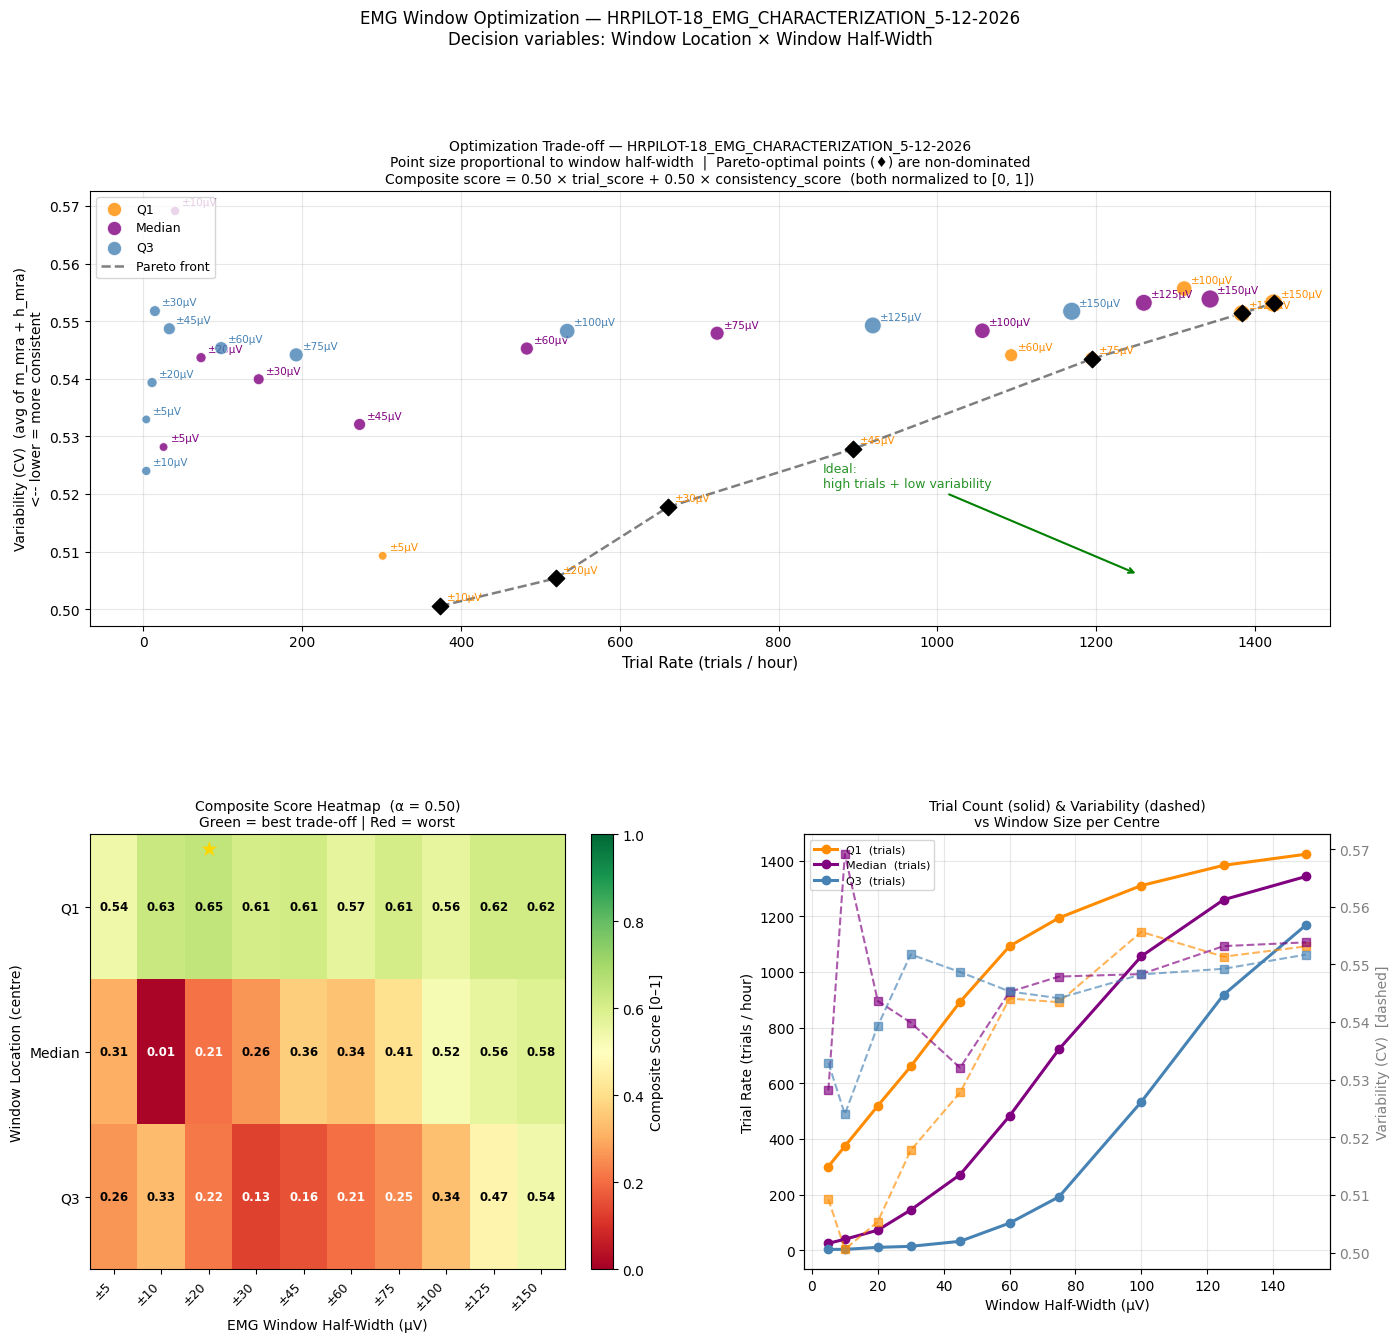

In [16]:
# ---- Section 7b: Optimization plots ----
# Pareto scatter, composite score heatmap, dual-axis trade-off lines.
# Re-run Section 7a with a different ALPHA to update the heatmap and ranking.S
plot_optimization(opt_rows, opt_info, hrs2_header)